# Trading With the Market: Turning Regimes Into Risk Control

### Motivation

While analysing markets, I realized that most strategies work beautifully in trending markets, but fail during bear phases, sideways corrections, or volatility spikes. Profits built over weeks often got erased in just a few bad phases.

That’s when I realized:

> **Trading strategies don’t fail because the logic is wrong. They fail because they are used in the wrong market environment.**

This project is an attempt to translate that qualitative understanding into a quantitative framework.

---

## Project Overview

In this notebook, we build a complete regime-based trading framework to:

- Understand market behavior using price and breadth data  
- Classify markets into bull, bear, high-volatility, and low-volatility regimes using Random Forest Model
- Stabilize noisy signals using persistence filters  
- Construct a four-regime adaptive exposure strategy and a Crash Hedge Strategy
- Add realistic execution logic  
- Backtest and evaluate performance against Buy & Hold  

The focus is not on predicting prices, but on:

> **Adapting risk and position sizing to changing market regimes.**


## Steps to Perform in This Project

1. Import libraries and load market data  
2. Build index-level and market breadth inputs
5. Define raw market regimes using rolling statistics  
3. Engineer trend, volatility, and breadth-based features  
4. Perform quality checks on features  
7. Train ML Models for Regime Classification
8. Classification Metrics for Each Regime  
9. Understand Feature Importance
10. Backtest the strategy   

Let’s begin!


In [56]:
from IPython.display import HTML

with open(
    "C:\\Users\\Aagrim\\Downloads\\regime_strategy_architecture.html",
    "r",
    encoding="utf-8"
) as f:
    html_content = f.read()

HTML(html_content)

In [1]:
# importing necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Index Data and Market Breadth Inputs

We start by building the primary data sources for the project.

- First, we download daily OHLCV data for a broad market index.
- Second, using all individual stocks within the index universe, we compute **market breadth metrics** that describe what’s happening beneath the surface.

Market breadth captures:
- Number of stocks above/below key moving averages  
- Number of stocks with large daily moves  
- Participation across the universe  

This helps us avoid relying only on index prices, which can often be dominated by a few large-cap stocks.


In [2]:
def fetch_historical_data(symbol, start_date, end_date):
    # Download historical data
    # threads=True speeds up download when fetching multiple symbols with threads=true 
    # multiple tickers are simultaneously getting downloaded.
    # group_by="symbol" ensures consistent structure across assets i.e. all data of one stock
    # gets grouped under its corresponding ticker.

  data = yf.download(symbol,start=start_date,end=end_date,threads=True,group_by="symbol")

    # yfinance returns MultiIndex columns when group_by="symbol" is used
    # For single-symbol downloads, flatten columns to standard OHLCV format
    # What essentially the above line mean is suppose, you download AAPL stock data in that case
    # case, every column will have two levels : ('AAPL', 'Close')
    #                                            ('AAPL, 'OPEN') and so on... which is effectively 
    # redundant. SO, yeah in order to truncate AAPL ticker symbol just get_level_values(1) which means access only the Standard OHLCV data for one stock
    # in case, multiple stocks exist then multi index is effective. As in that case, you would need to have (ticker, column name) pair.

  if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(1)
  return data


In [3]:
def calculate_daily_indicators(data):
  #Computing basic daily indicators used for calculating Market Breadth
    data['MA20'] = data['Close'].rolling(window=20, min_periods=1).mean()     #calculating MA20
    data['MA50'] = data['Close'].rolling(window=50, min_periods=1).mean()     #calculating MA50
    data['Daily_Return'] = data['Close'].pct_change() * 100                   #percentage change in a day
    data['5Day_Return'] = (data['Close'] / data['Close'].shift(5) - 1) * 100  #percentage change in 5 days
    return data

In [4]:
def scan_single_stock_historical(symbol, start_date, end_date):
    
#Scans historical price data for a single stock and generates
# daily technical condition flags.Then it returns a list of daily signal dictionaries
    
    data = fetch_historical_data(symbol, start_date, end_date)

    data = calculate_daily_indicators(data)
    results = []

    # Start from index 50 to ensure MA50 is fully formed as MA20 will easily be formed after 20 trading days 
    # and MA50 would require 50 trading days to completely form.
    for i in range(50, len(data)):
        day = data.iloc[i]

    # Building a daily signal snapshot
        results.append({
            'Symbol': symbol,
            'Date': day.name.strftime('%Y-%m-%d'),

            # Price & volume
            'Close': day['Close'],
            'Volume': day['Volume'],

            # Moving averages
            'MA20': day['MA20'],
            'MA50': day['MA50'],

            # Returns
            'Daily_Return': day['Daily_Return'],
            '5Day_Return': day['5Day_Return'],

            # Trend conditions
            'Above_MA20': day['Close'] > day['MA20'],
            'Below_MA20': day['Close'] < day['MA20'],
            'Above_MA50': day['Close'] > day['MA50'],
            'Below_MA50': day['Close'] < day['MA50'],

            # Large daily move flags (momentum / shock detection)
            'Up_4.5pct_Today': day['Daily_Return'] >= 4.5,
            'Down_4.5pct_Today': day['Daily_Return'] <= -4.5,

            # Large multi-day move flags (short-term momentum)
            'Up_20pct_5Days': day['5Day_Return'] >= 20,
            'Down_20pct_5Days': day['5Day_Return'] <= -20
        })
    return results

In [5]:
# sort of a scanner that runs on multiple stocks and combine all the results into big dataset.

def scan_all_stocks(symbols, start_date, end_date):
#Runs the historical scanner across a list of symbols and aggregates results.
  all_results = []
  for symbol in symbols:    # loops through each stock
    res = scan_single_stock_historical(symbol, start_date, end_date)   # scans one stock then calls our prev function 
# in order to perform tasks like: Download Historical data, calculate indicators, create daily signal snapshot
    all_results.extend(res)   ## Now add these results into a super list which is all_results
    print(f"{symbol}: {len(res)} days processed")  # print progress of how many trading days of a stock has been processed
  return pd.DataFrame(all_results)    ## Convert list into Dataframe 

In [6]:
# It takes stock-level daily signals and creates a market - wide daily summary. It takes input as Dataframe
# and just group by 'date' in order to group all stocks belonging to the same day together
# .agg : calculates or performs various statistical tasks like Counts the no. of symbols or stocks or a particular
# day. and like calculating the no. of stocks following conditions like Above_20MA, etc.
def generate_daily_summary(df):
  
   daily_summary = df.groupby('Date').agg({
        'Symbol': 'count',
        'Above_MA20': 'sum',
        'Below_MA20': 'sum',
        'Above_MA50': 'sum',
        'Below_MA50': 'sum',
        'Up_4.5pct_Today': 'sum',
        'Down_4.5pct_Today': 'sum',
        'Up_20pct_5Days': 'sum',
        'Down_20pct_5Days': 'sum'
    }).reset_index()
# Now, here after grouping date becomes an index. So, in order to convert Date into normal column,
# we are using reset_index()

   daily_summary.columns = [
        'Date', 'Total_Stocks_Scanned',
        'Stocks_Above_MA20', 'Stocks_Below_MA20',
        'Stocks_Above_MA50', 'Stocks_Below_MA50',
        'Stocks_Up_4.5pct_Today', 'Stocks_Down_4.5pct_Today',
        'Stocks_Up_20pct_5Days', 'Stocks_Down_20pct_5Days'
    ]  ## Here, we are just changing the names of the columns from Symbol to Total_Stocks_Scanned, etc.
   return daily_summary.sort_values('Date')    ## returning the daily summary by sorting it as per the date

In [7]:
def save_detailed_results(df, filename="data.csv"):
  #saves as a csv file
    df.to_csv(filename, index=False)
    print(f" Saved: {filename}")

In [8]:
import pandas as pd
import yfinance as yf

def download_nifty_index_ohlc(start_date, end_date, filename="nifty50_ohlc.csv"):
### Downloads historical OHLC data for the NIFTY 50 index from Yahoo Finance
### and saves it to a CSV file.
    
    # '^NSEI' is the ticker symbol for NIFTY 50 on Yahoo Finance
    ticker = "^NSEI"
    print(f"Downloading NIFTY 50 Index OHLC data for {ticker}")
    
    nifty50_data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    # auto_adjust = True means adjusting prices for things like dividends and splits.
    
    if nifty50_data.empty:  #In case, yfinance returns nothing then no data found.
        print(" Warning: No Index data found. Check your connection or ticker symbol.")
        return None
        
    ohlc_df = nifty50_data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()   #Keeps only ohlcv data or columns.
    ohlc_df.reset_index(inplace=True)    # Initially, date is the index. Now, after reset_index -> date becomes a normal column.
    
    # Flatten columns if yfinance returns multi-index headers. Sometimes, yfinance returns Price followed by Open -> High 
    # instead of: Open -> high so, if isinstance line, to remove multindex.
    if isinstance(ohlc_df.columns, pd.MultiIndex):
        ohlc_df.columns = [col[0]  for col in ohlc_df.columns]
        # the above ohlc_df.columns is essentially for every column; col = ('open', ''), picks up the very first 
        # element of the tuple like after it would be ['Open' , 'High', ...]
    ohlc_df.to_csv(filename, index=False)  # Index = 'False' here controls whether pandas should save the Dataframe Index.
    # for instance without this, it would look like    Date       Close
                                                 #   0  2023-04-01 23000 # where 0 is pandas index with index = 'False, it would be much more cleaner
    print(f" Saved Index OHLC to: {filename}")
    return ohlc_df

if __name__ == "__main__":    ## main execution block (could be redundant for our case as we have all the functions defined in the same ipynb file.
    # 1. Define historical scan window (3-year window: gives the 90-day rolling
    #    z-score baseline enough history to classify regimes and produce more
    #    Bull/Bear/High-Vol transitions for the models to learn from)
    start_date = "2023-01-01"
    end_date = "2026-01-01"

    # 2. Extract and save the exact OHLC data of the NIFTY 50 Index
    nifty_50 = download_nifty_index_ohlc(start_date, end_date, "nifty50_ohlc.csv") 

    # 3. Automatically fetch NIFTY 50 stock tickers directly from the official NSE link
    print("Fetching NIFTY 50 stock tickers directly from NSE...")
    try:
        nse_nifty50_url = "https://archives.nseindia.com/content/indices/ind_nifty50list.csv"
        df_symbols = pd.read_csv(nse_nifty50_url)[['Symbol']].copy()   ## loads the list
        print(f"Loaded {len(df_symbols)} constituent symbols directly from NSE.")
    ## in case, NSE fails then use below: 
    # loading a local csv taken it up as backup
    except Exception as e:
        print(f"Could not stream from NSE. Trying local fallback path... Error: {e}")
        # Local system absolute path fallback from your previous setup
        csv_path = r"C:\Users\Aagrim\Downloads\MLT02-Inclass-Exercises-File\MLT02 Inclass Exercises File\MLT02_data_ind_nifty50list"
        df_symbols = pd.read_csv(csv_path)[['Symbol']].copy()

    # Formulate Yahoo-compatible symbols (.NS) like NSE gives: ReLIANCE but yf needs: RELIANCE.NS
    df_symbols['Yahoo_Symbol'] = df_symbols['Symbol'] + '.NS'
    symbols = df_symbols['Yahoo_Symbol'].tolist()   # Converts the Yahoo_symbols to lists.

    # 4. Scan across the 50 individual stocks
    print(f" Initiating breadth scan for {len(symbols)} tickers...")
    all_results_df = scan_all_stocks(symbols, start_date, end_date)
    save_detailed_results(all_results_df, "all_stock_data.csv")   # Now, here scans across all the 50 individual stocks and then for 
    # each stock: it downloads price data and then calculates MA20, MA50, etc
    

    # 5. Generate and save market breadth summary
    daily_summary_df = generate_daily_summary(all_results_df)
    save_detailed_results(daily_summary_df, "daily_summary.csv")
    # Finally, generates the summary of the market breadth using individual stocks for instance : date     stocks Above MA20     Stocks Below MA20
                                                                                  #               jan 1    2                         1

[*********************100%***********************]  1 of 1 completed


 Saved Index OHLC to: nifty50_ohlc.csv
Fetching NIFTY 50 stock tickers directly from NSE...
Loaded 50 constituent symbols directly from NSE.
 Initiating breadth scan for 50 tickers...


C:\Users\Aagrim\AppData\Local\Temp\ipykernel_29880\3992749541.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,start=start_date,end=end_date,threads=True,group_by="symbol")
[*********************100%***********************]  1 of 1 completed
C:\Users\Aagrim\AppData\Local\Temp\ipykernel_29880\3992749541.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,start=start_date,end=end_date,threads=True,group_by="symbol")


ADANIENT.NS: 690 days processed


[*********************100%***********************]  1 of 1 completed
C:\Users\Aagrim\AppData\Local\Temp\ipykernel_29880\3992749541.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,start=start_date,end=end_date,threads=True,group_by="symbol")


...

TRENT.NS: 690 days processed


[*********************100%***********************]  1 of 1 completed
C:\Users\Aagrim\AppData\Local\Temp\ipykernel_29880\3992749541.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,start=start_date,end=end_date,threads=True,group_by="symbol")


ULTRACEMCO.NS: 690 days processed


[*********************100%***********************]  1 of 1 completed


WIPRO.NS: 690 days processed
 Saved: all_stock_data.csv
 Saved: daily_summary.csv


In [9]:
#loads the csv file created as data (market breadth data, calculated from individual NIFTY50 Stocks)
data = pd.read_csv("daily_summary.csv",index_col=0,parse_dates=True)
data

,Total_Stocks_Scanned,Stocks_Above_MA20,Stocks_Below_MA20,Stocks_Above_MA50,Stocks_Below_MA50,Stocks_Up_4.5pct_Today,Stocks_Down_4.5pct_Today,Stocks_Up_20pct_5Days,Stocks_Down_20pct_5Days
Date,,,,,,,,,
2023-03-15,49,10,39,11,38,1,0,0,0
2023-03-16,49,15,34,14,35,1,1,0,0
2023-03-17,49,18,31,17,32,0,0,0,0
2023-03-20,49,15,34,16,33,0,0,0,0
2023-03-21,49,17,32,16,33,0,0,0,0
...,...,...,...,...,...,...,...,...,...
2025-12-24,50,30,20,26,24,0,0,0,0
2025-12-26,50,28,22,25,25,0,0,0,0
2025-12-29,50,22,28,23,27,0,0,0,0


In [10]:
#downloads the file in an excel format
data.to_excel("daily_stock_summary.xlsx", index=False)    # then we just created an excel files of the daily_stock_summary

In [11]:
nifty_50

,Date,Open,High,Low,Close,Volume
0,2023-01-02,18131.699219,18215.150391,18086.500000,18197.449219,256100
1,2023-01-03,18163.199219,18251.949219,18149.800781,18232.550781,208700
2,2023-01-04,18230.650391,18243.000000,18020.599609,18042.949219,235200
3,2023-01-05,18101.949219,18120.300781,17892.599609,17992.150391,269900
4,2023-01-06,18008.050781,18047.400391,17795.550781,17859.449219,238200
...,...,...,...,...,...,...
735,2025-12-24,26170.650391,26236.400391,26123.000000,26142.099609,188800
736,2025-12-26,26121.250000,26144.199219,26008.599609,26042.300781,142200
737,2025-12-29,26063.349609,26106.800781,25920.300781,25942.099609,234300
738,2025-12-30,25940.900391,25976.750000,25878.000000,25938.849609,396900


In [12]:
print(data.shape)
print(data.columns)
print(data.info())

(690, 9)
Index(['Total_Stocks_Scanned', 'Stocks_Above_MA20', 'Stocks_Below_MA20',
       'Stocks_Above_MA50', 'Stocks_Below_MA50', 'Stocks_Up_4.5pct_Today',
       'Stocks_Down_4.5pct_Today', 'Stocks_Up_20pct_5Days',
       'Stocks_Down_20pct_5Days'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 690 entries, 2023-03-15 to 2025-12-31
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Total_Stocks_Scanned      690 non-null    int64
 1   Stocks_Above_MA20         690 non-null    int64
 2   Stocks_Below_MA20         690 non-null    int64
 3   Stocks_Above_MA50         690 non-null    int64
 4   Stocks_Below_MA50         690 non-null    int64
 5   Stocks_Up_4.5pct_Today    690 non-null    int64
 6   Stocks_Down_4.5pct_Today  690 non-null    int64
 7   Stocks_Up_20pct_5Days     690 non-null    int64
 8   Stocks_Down_20pct_5Days   690 non-null    int64
dtypes: int64(9)
mem

In [13]:
print(nifty_50.shape)
print(nifty_50.columns)
print(nifty_50.info())

(740, 6)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    740 non-null    datetime64[ns]
 1   Open    740 non-null    float64       
 2   High    740 non-null    float64       
 3   Low     740 non-null    float64       
 4   Close   740 non-null    float64       
 5   Volume  740 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 34.8 KB
None


## Step 2: Market Regime Definition Using Trend & Volatility

In this step, we transform raw price data into structured **market regime labels** that serve as the target variable for the project.

We:
- Compute daily returns, rolling volatility, and lookback trend from prices.  
- Normalize trend and volatility using rolling z-scores so regime thresholds adapt over time.  
- Classify each day into raw Bull/Bear and High/Low volatility states based on these z-scores.  
- Apply persistence filters, requiring regimes to persist for at least **4 out of the last 5 days**, to reduce noise and whipsaws.  
- Drop initial periods with insufficient rolling data.

The output is a clean set of raw and stable regime indicators that describe the **market environment** and form the foundation for building the adaptive strategy in the next steps.

In [14]:
def define_market_regimes(prices, lookback=20):
## Defines market regimes(y variable) based on trend and volatility characteristics.

   # ----------------------------------------
   # Compute returns and rolling volatility
   # ----------------------------------------
   returns = prices.pct_change()
   rolling_vol = returns.rolling(lookback).std()
   trend = prices.pct_change(lookback)

   regimes = pd.DataFrame(index=prices.index)    ## creating an empty regimes dataframe using the same index(dates) as my prices data.

   # ---------------------------------------------------------
   # Normalize volatility and trend using rolling z-scores
   # ---------------------------------------------------------
   # Z-scores are computed relative to a longer-term (90-day) baseline
   # This allows regime classification to adapt over time

   vol_zscore = (rolling_vol - rolling_vol.rolling(90).mean()) / rolling_vol.rolling(90).std() 
    # Current rolling volatility minus the 90-day moving average of rolling volatility.divided by the 90-day moving avg of rolling_vol
   trend_zscore = (trend - trend.rolling(90).mean()) / trend.rolling(90).std()
    #Current trend minus the 90-day moving average of trend divided by 90-day moving average of trend.

   # ---------------------------------------------------------
   # Raw regime classification
   # ---------------------------------------------------------
   # Volatility regimes
   regimes["High_Volatility"] = (vol_zscore > 0.5).astype(int)
   regimes["Low_Volatility"] = (vol_zscore < -0.5).astype(int)

   # Trend regimes
   regimes["Bull_Market"] = (trend_zscore > 0.5).astype(int)
   regimes["Bear_Market"] = (trend_zscore < -0.5).astype(int)

   # ---------------------------------------------------------
   # Regime persistence filters
   # ---------------------------------------------------------
   # Require regime conditions to persist for at least
   # 4 out of the last 5 days to reduce whipsaws
   regimes["Stable_Bull"] = (
       (regimes["Bull_Market"] == 1) &
       (regimes["Bull_Market"].rolling(5).sum() >= 4)  # 4 days out of last 5 days regime was a 'bull market'. this will ensure that it's not an outlier.
   ).astype(int)

   regimes["Stable_Bear"] = (
       (regimes["Bear_Market"] == 1) &
       (regimes["Bear_Market"].rolling(5).sum() >= 4)
   ).astype(int)

   regimes["Stable_Low_Vol"] = (
       (regimes["Low_Volatility"] == 1) &
       (regimes["Low_Volatility"].rolling(5).sum() >= 4)
   ).astype(int)

   # Drop initial rows with insufficient data for rolling calculations
   regimes = regimes.dropna()

   return regimes

## Step 3: Feature Creation

Using index prices and market breadth data, we construct features that capture:

- **Trend** → directional movement of the market  
- **Volatility** → risk and uncertainty  
- **Breadth strength & participation** → how widely moves are supported  

These features translate raw market data into signals that describe the *state* of the market rather than just its level.


For example, **Market_Momentum**((Stocks Above MA20 − Stocks Below MA20) / Total Stocks) measures the net balance of stocks above and below their short-term trend, helping distinguish sustainable trends from fragile rallies, while **Participation_Rate** ((Stocks Up + Stocks Down) / Total Stocks)captures how many stocks are actively moving, signaling whether volatility is expanding beneath the surface.


In [15]:
def create_regime_features(market_breadth, prices):
## Constructs predictive regime-level features using market breadth
## and index price data.
## All features are shifted to avoid look-ahead bias.
   print("\nSTEP 3: CREATING PREDICTIVE FEATURES...")

   features = pd.DataFrame(index=market_breadth.index)   # Creating empty df with index as the same as that of market breadth data.

   features['Advance_Decline_Ratio'] = (
      (market_breadth['Stocks_Up_4.5pct_Today'] + 1) /
      (market_breadth['Stocks_Down_4.5pct_Today'] + 1)
   )

   features['MA20_Strength'] = (
      market_breadth['Stocks_Above_MA20'] /
      market_breadth['Total_Stocks_Scanned']
   )

   features['Market_Momentum'] = (
      (market_breadth['Stocks_Above_MA20'] - market_breadth['Stocks_Below_MA20']) /
      market_breadth['Total_Stocks_Scanned']
   )

   features['Participation_Rate'] = (
      (market_breadth['Stocks_Up_4.5pct_Today'] + market_breadth['Stocks_Down_4.5pct_Today']) /
      market_breadth['Total_Stocks_Scanned']   # +-4.5% move a day
   )

   features['Extreme_Move_Ratio'] = (
      (market_breadth['Stocks_Up_20pct_5Days'] + market_breadth['Stocks_Down_20pct_5Days']) /
      market_breadth['Total_Stocks_Scanned']   # +-20% move a day
   )

   features['Extreme_Momentum_Bias'] = (
      (market_breadth['Stocks_Up_20pct_5Days'] - market_breadth['Stocks_Down_20pct_5Days']) / market_breadth['Total_Stocks_Scanned'] 
         # why stocks_up - stocks_down?? because here positive mesn strong upside momentum and negative means downside momentum. 
   )

   features['Extreme_Volatility_Indicator'] = (
      features['Extreme_Move_Ratio'].rolling(5).mean() /
      features['Extreme_Move_Ratio'].rolling(20).mean()
   )
   returns = prices.pct_change()
   features['Price_Volatility_Ratio'] = (
      (returns.rolling(5).std() / returns.rolling(20).std())
   )

   features['Trend_Strength'] = (
      (prices / prices.rolling(20).mean() - 1)
   )
   features = features.shift(1)   # Shifting everything in order to avoid look-ahead bias.

   lag_features = [
   'Advance_Decline_Ratio', 'MA20_Strength', 'Market_Momentum',
   'Participation_Rate', 'Extreme_Move_Ratio', 'Extreme_Momentum_Bias'
   ]
   for feat in lag_features:
     features[f'{feat}_lag1'] = features[feat].shift(1)    # one more lag so that the model learns the fact, "if market
       # momentum has been increasing for two consecutive days, a bull market is more likely.

   features['Momentum_Change_5d'] = features['Market_Momentum'].diff(5)  # Positive means breadth has improved over the last week.
   features['Breadth_Acceleration'] = features['MA20_Strength'].pct_change(3)  # measures the percentage change in MA20 strength over 3 days.
   features['Extreme_Momentum_Change'] = features['Extreme_Momentum_Bias'].diff(5)
   features['Extreme_Move_Acceleration'] = features['Extreme_Move_Ratio'].pct_change(3)

   # Replace any divide-by-zero infinities (e.g. volatility ratios when a
   # rolling denominator is 0) with NaN -- scikit-learn rejects inf at fit().
   features = features.replace([np.inf, -np.inf], np.nan)   # scikit- learn cannot handle infinite values, so
    # they are converted to Nan

   # On a small universe (e.g. NIFTY 50) stocks rarely move +/-20% in 5 days,
   # so Extreme_Move_Ratio is 0 on most days and its derived ratio/acceleration
   # features become 0/0 -> undefined on the majority of rows. Dropping those
   # rows would discard almost the entire sample (the '7 rows' symptom).
   # Treat 'no extreme activity' as a neutral 0 instead of dropping the row.
   neutral_fill = ['Extreme_Volatility_Indicator',
                   'Extreme_Move_Acceleration',
                   'Breadth_Acceleration']
   for col in neutral_fill:
       if col in features.columns:
           features[col] = features[col].fillna(0)   # as it is uncommon for any Nifty 50 stock to have extreme moves. So, instead of dropping
           # almost every row, just fill them with zeors

   # Remove only the initial warm-up rows (rolling/shift history) like MA20, MA50,etc
   features = features.dropna()

   print(f" Features created successfully: {features.shape[1]} features, {features.shape[0]} rows")

   return features

In [16]:
# ---------------------------------------------------------
# Align market breadth data with price series
# ---------------------------------------------------------
# Create a working copy of market breadth data
market_breadth = data.copy()

nifty_50['Date'] = pd.to_datetime(nifty_50['Date']) # converting date column as datetime object instead of strings.
prices = nifty_50.set_index('Date')['Close']  # exctracting Close prices of the nifty_50 index and storing it in prices in which date is the index.
# Find common dates between breadth data and price data
# This ensures features and targets are perfectly aligned
common_dates = market_breadth.index.intersection(prices.index)
# Subset both datasets to the shared date range
market_breadth = market_breadth.loc[common_dates]  #exctrating data keeping common_dates as the index.
prices = prices.loc[common_dates]

In [17]:
# ---------------------------------------------------------
# Generate regime-level predictive features
# ---------------------------------------------------------
# Transforms aligned market breadth and price data into lagged, look-ahead-safe features for regime modeling
features = create_regime_features(market_breadth, prices)


STEP 3: CREATING PREDICTIVE FEATURES...
 Features created successfully: 19 features, 669 rows


In [18]:
features_before = features.copy()

In [19]:
# ---------------------------------------------------------
# Feature normalization & outlier control (preprocessing the features before they're fed into ML model.
# ---------------------------------------------------------
# Log-transform skewed ratio-based features
log_features = [
    "Advance_Decline_Ratio",
    "Advance_Decline_Ratio_lag1",
    "Extreme_Move_Ratio",
    "Extreme_Move_Ratio_lag1",
    "Extreme_Momentum_Bias",
    "Extreme_Momentum_Bias_lag1"
]

for col in log_features: # looping through each log_features
    if col in features.columns:     # if for instance, col = 'Advance_Decline_Ratio', then transform it by using
        # log clipping in order to prevent skewness or attain uniform scaling for all the features. This is done to ensure that our Model doesn't give any undue importance to 
        # a single feature beacuse of its value.
        # clip lower bound just above -1 so log1p never returns -inf
        features[col] = np.log1p(features[col].clip(lower=-0.999999))

# ---------------------------------------------------------
# Clip acceleration features to control noise
# ---------------------------------------------------------
# Acceleration and change-based features are highly volatile
# Clipping prevents single-day shocks from dominating learning
clip_features = ["Breadth_Acceleration", "Extreme_Move_Acceleration"]

for col in clip_features:
    if col in features.columns:
        # Limit extreme outliers while preserving direction
        features[col] = features[col].clip(-3, 3)   # anything below -3 wll be capped to -3. Anything above 3 will be capped to 3.

## Step 4: Quality Check of Features

Before using the engineered features for modeling, we perform sanity checks to ensure:

- No extreme outliers dominate the signals  
- Ratios are well-behaved
- Check correlation matrix to spot highly correlated features
- Missing values are handled  
- Feature distribution using histograms to check for skewness or fatty tails

This step ensures the model learns from meaningful structure, not data artifacts.

In [20]:
# Check total missing values per column
print(features.isna().sum())

Advance_Decline_Ratio           0
MA20_Strength                   0
Market_Momentum                 0
Participation_Rate              0
Extreme_Move_Ratio              0
Extreme_Momentum_Bias           0
Extreme_Volatility_Indicator    0
Price_Volatility_Ratio          0
Trend_Strength                  0
Advance_Decline_Ratio_lag1      0
MA20_Strength_lag1              0
Market_Momentum_lag1            0
Participation_Rate_lag1         0
Extreme_Move_Ratio_lag1         0
Extreme_Momentum_Bias_lag1      0
Momentum_Change_5d              0
Breadth_Acceleration            0
Extreme_Momentum_Change         0
Extreme_Move_Acceleration       0
dtype: int64


In [21]:
print(features.describe())

       Advance_Decline_Ratio  MA20_Strength  Market_Momentum  \
count             669.000000     669.000000       669.000000   
mean                0.792927       0.594796         0.189593   
std                 0.333832       0.212779         0.425558   
min                 0.071459       0.061224        -0.877551   
25%                 0.693147       0.420000        -0.160000   
50%                 0.693147       0.620000         0.240000   
75%                 1.098612       0.760000         0.520000   
max                 2.890372       0.980000         0.960000   

       Participation_Rate  Extreme_Move_Ratio  Extreme_Momentum_Bias  \
count          669.000000          669.000000             669.000000   
mean             0.016483            0.001068               0.000530   
std              0.036505            0.004852               0.004962   
min              0.000000            0.000000              -0.020203   
25%              0.000000            0.000000               0.0

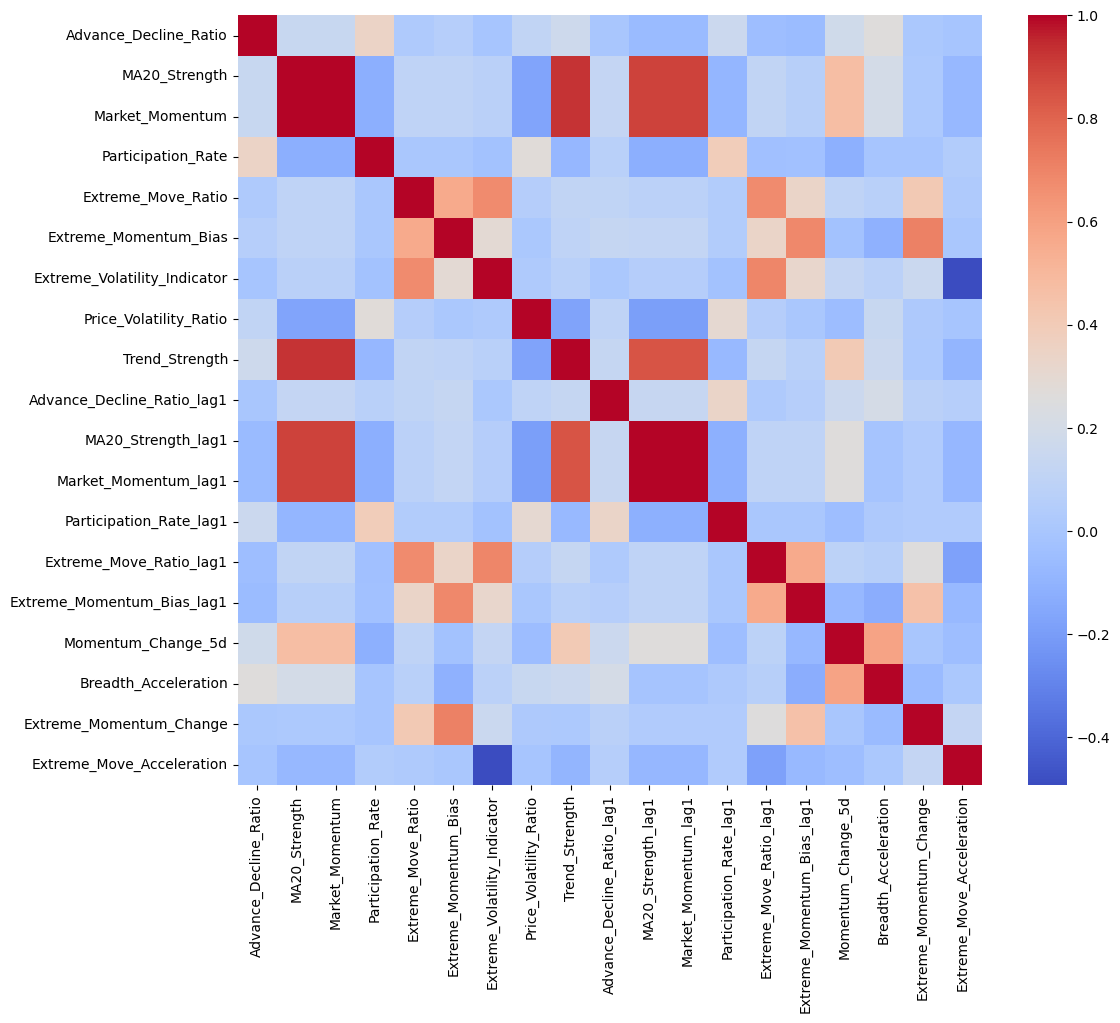

In [22]:
# Feature correlation analysis
corr = features.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm')   # annot = False means rather than seeing numerical values, colors would be visible.
plt.show()
# other heatmaps could be Missing value heatmaps, feature importance heatmap, confusion matrix heat map (including false positives, false negatives, true negatives and true positives,etc)

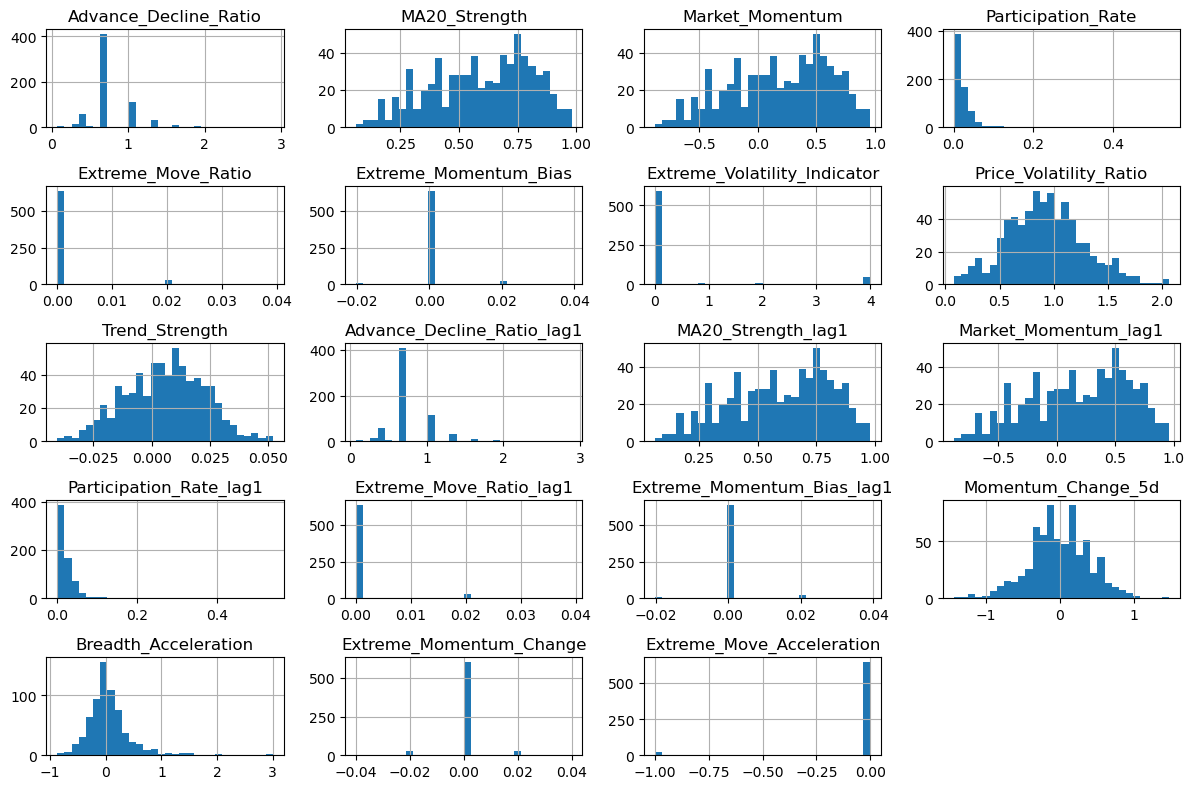

In [23]:
# Feature distribution inspection for skewness and outliers
features.hist(figsize=(12,8), bins=30)  # bins refer to no. of intervals and groups the data range is divide into when creating the histogram.
plt.tight_layout()
plt.show()

In [24]:
# the code compares the two (festures_before and features) and identifies the columns that are different.
changed_features = [
    col for col in features.columns # means for every column in features
    if col in features_before.columns    # check whether the columns in features exist in features_before(original df)
    and not np.allclose(                     # checks which columns have got changed after preprocessing while also filling nans (if exist) with 0 as NaN == NaN is False.
        features_before[col].fillna(0),     # and then keep only those features whose values before and sfter preprocessing are not the same.
        features[col].fillna(0)            
    )
]

In [25]:
def plot_feature_changes(before, after, cols, bins=50):
    for col in cols:
        plt.figure(figsize=(8, 4))
        plt.hist(before[col].dropna(), bins=bins, alpha=0.6, label='Before')
        plt.hist(after[col].dropna(), bins=bins, alpha=0.6, label='After')
        plt.title(f"{col}: Before vs After")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

Changed features: ['Advance_Decline_Ratio', 'Extreme_Move_Ratio', 'Extreme_Momentum_Bias', 'Advance_Decline_Ratio_lag1', 'Extreme_Move_Ratio_lag1', 'Extreme_Momentum_Bias_lag1', 'Breadth_Acceleration']


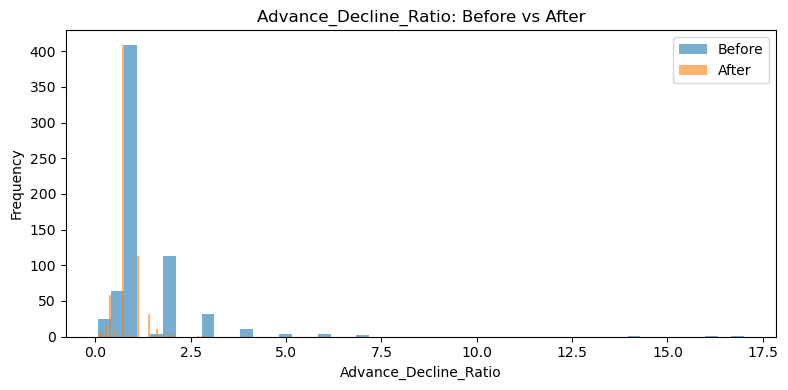

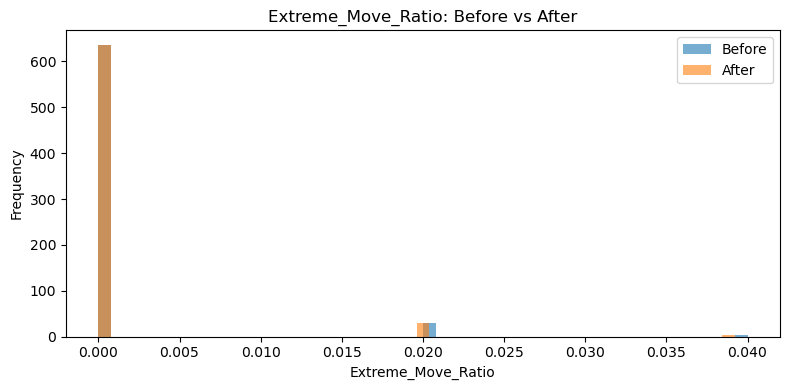

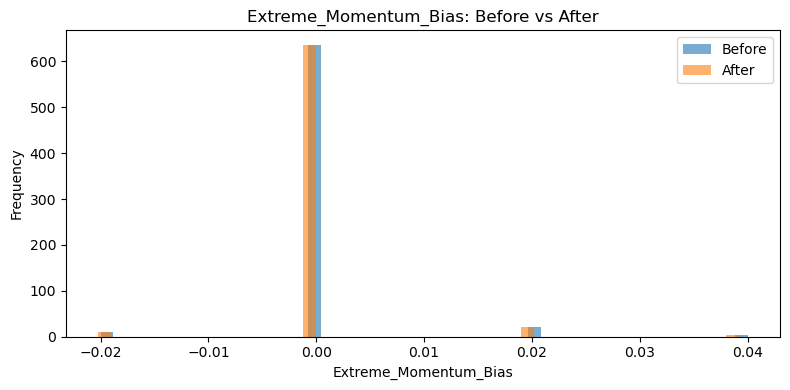

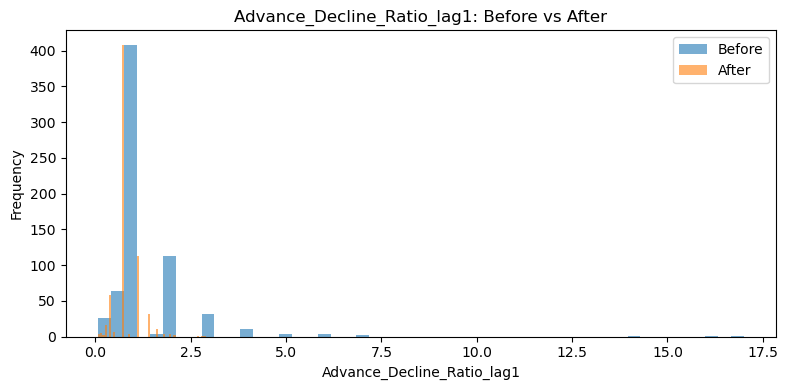

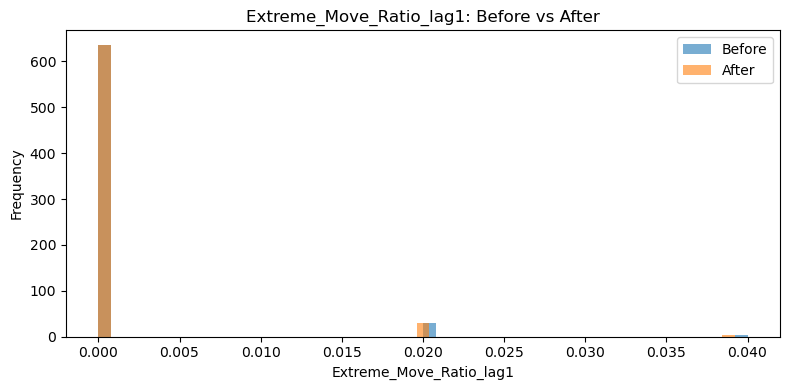

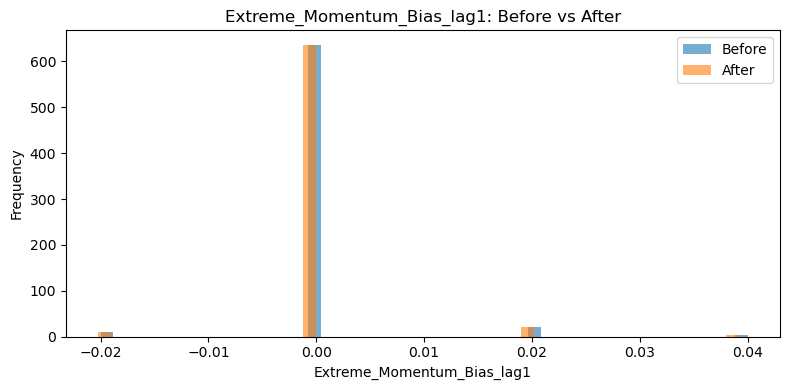

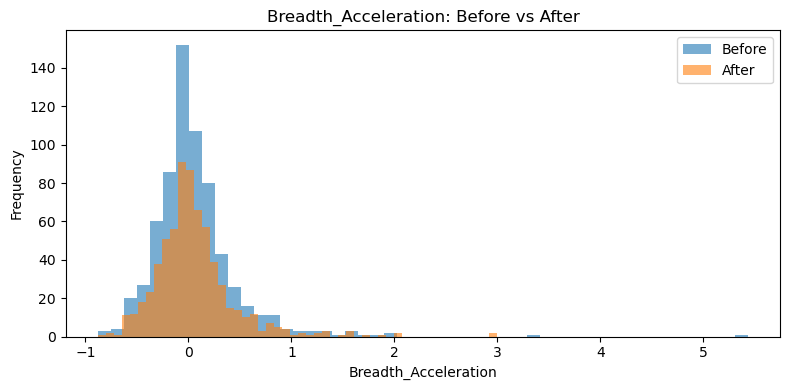

In [26]:
def plot_feature_changes(before, after, cols, bins=50): # takes 4 inputs : df before preprocessing, df after preprocessing, list of columns you want to compare
    # no. of intervals in the histogram.
    for col in cols:   # iterates through cols and create a plotting area of width = 8 and height = 4
        plt.figure(figsize=(8, 4))
        # Filter out non-finite values (NaN and inf) from 'before' data
        data_before = before[col].dropna()
        data_before = data_before[np.isfinite(data_before)]

        # Filter out non-finite values (NaN and inf) from 'after' data
        data_after = after[col].dropna()
        data_after = data_after[np.isfinite(data_after)]

        # Check if there's data to plot after filtering
        if not data_before.empty:
            plt.hist(data_before, bins=bins, alpha=0.6, label='Before')
        else:
            print(f"Warning: No finite data to plot for 'Before' in column '{col}'.")

        if not data_after.empty:
            plt.hist(data_after, bins=bins, alpha=0.6, label='After')
        else:
            print(f"Warning: No finite data to plot for 'After' in column '{col}'.")

        plt.title(f"{col}: Before vs After")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

print("Changed features:", changed_features)
plot_feature_changes(features_before, features, changed_features)

## Step 5: Train Time-Series ML Models for Regime Classification

In this step, we train machine learning models to **learn and predict market regimes** from engineered features.

We:
- Align feature data with regime labels by date and remove missing values.  
- Perform a time-aware train–test split to respect chronological order.  
- Use **Random Forest classifiers** with class balancing to handle regime imbalance.  
- Apply **walk-forward TimeSeries cross-validation** on the training set to assess stability across different market phases.  
- Train one **binary model per regime** (Bull, Bear, Low Vol, High Vol, etc.) instead of a single multi-class model.  
- Evaluate each model on a held-out test set using accuracy.  
- Save all trained models and diagnostics for later use.

This step converts engineered features into a set of predictive regime models, forming the bridge between **market data** and **regime-aware strategy construction** in the next stage.


In [27]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

def fit_evaluate_timeseries_rf(X, y, train_frac=0.7, n_splits=3, rf_kwargs=None): # training data --> 0.7 and testing data --> 0.3 and no. of splits = 3 (time-series validation folds)
## Fits and evaluates a Random Forest classifier on time-series data.
# Handle optional model hyperparameters like max_depth and n_estimators
    rf_kwargs = rf_kwargs or {}  

    # ---------------------------------------------------------
    # Train / test split (time-aware)
    # ---------------------------------------------------------
    # Use the first `train_frac` portion for training
    # Remaining data is held out as a final test set
    n = len(X)
    cut = int(n * train_frac)    # suppose n = 2000 and train_frac = 0.7 so, split point is 1400
    X_train, X_test = X.iloc[:cut], X.iloc[cut:]
    y_train, y_test = y.iloc[:cut], y.iloc[cut:]

    # ---------------------------------------------------------
    # TimeSeries cross-validation on training data
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=n_splits)  # creating rolling validation windows. Suppose training data = 700 then in that case,
    # train : 1-175 validation: 176-350 and so on.
    cv_acc = []

    for tr_idx, val_idx in tscv.split(X_train):  # for each fold tr_idx and val_idx crete folds like # train : 1-175 validation: 176-350 and so on.
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]  # internally sklearn creates the indices for the training and validation part
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        # Check if there are at least two unique classes in the training split
        if y_tr.nunique() < 2:
            print(f"Skipping CV fold due to insufficient data for training (only one class present).")
            continue    # there might be a possibility that a training class only have a single class (for instance: only bull),
            # in such a case, it is worth skipping that fold due to insufficient data for training as the model would never learn the not bull phase(0).

        # Train model on current fold
        m = RandomForestClassifier(random_state=42, n_jobs=-1, **rf_kwargs) # random state: for reproducibility, n_jobs = -1 means use all the available cpu cores.
       # "**": unpacks the dictionry and rf_kwargs: allows to pass extra random forest parameters like n_estimators: 200, max_depth: 5.
        m.fit(X_tr, y_tr) # training of the model

        # Check if there are at least two unique classes in the validation split for evaluation
        if y_val.nunique() < 2:
             print(f"Skipping CV fold evaluation due to insufficient data for validation (only one class present).")
             continue

        cv_acc.append(accuracy_score(y_val, m.predict(X_val)))   ## append the accuracy of the model based on actual y_val and predicted value.

    # Final fit on full train
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **rf_kwargs)
    model.fit(X_train, y_train) # During cross-validation, model was temporarily trained for estimating performance. Now here, the model is fully trained on the complete
    # training data and then calculate the final accuracy using model.predict on the test data.

    # Simple test eval
    test_acc = accuracy_score(y_test, model.predict(X_test))

    report = {
        "cv_fold_accuracy": cv_acc,
        "cv_mean_accuracy": float(np.mean(cv_acc)) if cv_acc else np.nan,
        "test_accuracy": float(test_acc),
        "train_size": int(len(X_train)),
        "test_size": int(len(X_test)),
    }
    return model, report     # the report stores a dictionary containing various performance parameters.

In [28]:
# Below function is the main training controller for the whole market regime prediction system. 
# It takes : engineered features, regime labels, train one Random Forest classifier for each regime, Eva;uate each model using time-series validation
# Save all the trained models and reports into one .pkl file
def train_all_regime_models(features, regimes, output_path="regime_models.pkl"):
  # Stores trained models and their evaluation reports
    models = {}
    reports = {}

    # Align features & regimes labels by date
    common_index = features.index.intersection(regimes.index)
    X = features.loc[common_index]  # input features
    Y = regimes.loc[common_index]   # regime labels

  
    for regime in Y.columns:   # train one model per regime for example bull market
        print(f"\n Training model for regime: {regime}")
        y = Y[regime] # target for current regime (0/1) like y = Y['Bull_Market']. This becomes the target in this case.

        # Time-series RF with walk-forward CV and class balancing
        model, report = fit_evaluate_timeseries_rf(  # Calling the previous function for training the model
            X=X,   # X=X means X= market breadth features y = current regime
            y=y,
            train_frac=0.7,
            n_splits=3,   # 3 walk forward folds
            rf_kwargs={"n_estimators":100, "max_depth":10, "class_weight":"balanced"}
        )  # 100 rf, each tree can grow upto 10 levels, class_weight : balanced means suppose data is like: bull days:700
        ## bear days : 100 without balancing, the model would always predict bull because that would give higher accuracy.

        # Store model and diagnostics
        models[regime] = model
        reports[regime] = report
        print(report)

    # Save everything in one pickle file
    with open(output_path, "wb") as f:
        pickle.dump({"models": models, "reports": reports}, f)

    print(f"\nAll regime models saved to '{output_path}'")
    return models, reports


In [29]:
# 1. Create regime target labels from price series
regimes = define_market_regimes(prices, lookback=20)

# Align features & regimes labeled by date
common_index = features.index.intersection(regimes.index)
X = features.loc[common_index]
y = regimes.loc[common_index]

# Drop any remaining NaNs after alignment to ensure clean data for training
# This is crucial because define_market_regimes's final shift(1) introduces NaNs.
combined_data = pd.concat([X, y], axis=1)  # combining dataframe along columns
combined_data.dropna(inplace=True)
X = combined_data[X.columns]   # getting features column again
y = combined_data[y.columns]   # getting target columns again

# Split data into training and test sets
train_frac = 0.7
cut = int(len(X) * train_frac)
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]
regimes_clean = y_test.copy() # Rename y_test to regimes_clean for clarity in evaluation function

# 2. Train and save all models
models, reports = train_all_regime_models(X_train, y_train, output_path="market_regime_models.pkl")   # using previous functions to make model learn. 

# 3. Evaluate models on test set
acc_table = pd.DataFrame(columns=['Regime', 'Accuracy'])   ## Created an empty dataframe
for regime in regimes_clean.columns:  # looping through regimes (like bull, bear, low_vol, high_vol,etc)
    if regime in models:   ## check whether a trained model for a particular regime exists inside the models dictionary.
        model = models[regime]
        # Check if there are at least two unique classes in the test split for evaluation
        if y_test[regime].nunique() < 2:
            print(f"Skipping test evaluation for regime '{regime}' due to insufficient data (only one class present).")
            continue    # check if there are two unique labels, otherwise skip.
        test_acc = accuracy_score(regimes_clean[regime], model.predict(X_test))   # calculate accuracy for the actual regime and precdicted regimes.
        acc_table.loc[len(acc_table)] = [regime, test_acc]   # calculate accuracy for each regime. 
    else:
        print(f"Model for regime '{regime}' not found.")

print("\n Test Set Evaluation:")
print(acc_table)


 Training model for regime: High_Volatility
Skipping CV fold due to insufficient data for training (only one class present).
{'cv_fold_accuracy': [0.4444444444444444, 0.5308641975308642], 'cv_mean_accuracy': 0.4876543209876543, 'test_accuracy': 0.41134751773049644, 'train_size': 327, 'test_size': 141}

 Training model for regime: Low_Volatility
Skipping CV fold due to insufficient data for training (only one class present).
{'cv_fold_accuracy': [0.8024691358024691, 0.5432098765432098], 'cv_mean_accuracy': 0.6728395061728395, 'test_accuracy': 0.6879432624113475, 'train_size': 327, 'test_size': 141}

 Training model for regime: Bull_Market
Skipping CV fold due to insufficient data for training (only one class present).
{'cv_fold_accuracy': [0.9012345679012346, 0.5802469135802469], 'cv_mean_accuracy': 0.7407407407407407, 'test_accuracy': 0.8297872340425532, 'train_size': 327, 'test_size': 141}

 Training model for regime: Bear_Market
Skipping CV fold due to insufficient data for training

In [30]:
# ---------------------------------------------------------
# Align feature matrix with price data used for prediction
# ---------------------------------------------------------
# Ensure features and prices share the same timeline
common_index = features.index.intersection(prices.index)
X = features.loc[common_index]
close = prices.loc[common_index]

# ---------------------------------------------------------
# Initialize signal DataFrame
# ---------------------------------------------------------
# Stores regime predictions aligned with dates and prices
signals = pd.DataFrame(index=common_index) # create an empty dataframe
signals["Close"] = close  # adds closing price 

# ---------------------------------------------------------
# Generate regime signals using trained models
# ---------------------------------------------------------
# Each model predicts whether its regime is active (0/1)
for regime_name, model in models.items():    # for each regime and model it loops through 
    signals[regime_name] = model.predict(X)  # and based on market breadth, predicts out of the 4 which regime is currently active.

In [31]:
signals.tail()

,Close,High_Volatility,Low_Volatility,Bull_Market,Bear_Market,Stable_Bull,Stable_Bear,Stable_Low_Vol
Date,,,,,,,,
2025-12-24,26142.099609,1,1,0,1,0,0,0
2025-12-26,26042.300781,1,1,0,0,0,0,0
2025-12-29,25942.099609,1,1,0,1,0,0,0
2025-12-30,25938.849609,0,0,0,1,0,0,0
2025-12-31,26129.599609,0,0,0,0,0,0,0


In [32]:
signals.to_csv("market_regime_signals.csv")

## Step 6: Detailed Classification Metrics for Each Regime

In this step, we go beyond accuracy and evaluate each regime model using:

- **Precision** → how reliable positive regime predictions are  
- **Recall** → how well the model captures actual regime occurrences  
- **F1-score** → balance between precision and recall  

For each trained binary regime model, we generate a full classification report on the test set.

This helps us understand:
- Which regimes are easier or harder to detect,  
- Whether the model is biased toward false positives or false negatives, and  
- If regime predictions are robust enough to be used in downstream strategy logic.


In [33]:
from sklearn.metrics import classification_report    # gives summary of classification performance. 

print("\n" + "="*50)
print("PRECISION, RECALL, F1-SCORE FOR EACH REGIME")
print("="*50)

for regime_name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n {regime_name}:")
    print(classification_report(y_test[regime_name], y_pred))  # loops through each regime and model and based on that, creates classification_report depending on how well the model 
    # has predicted the regime.


PRECISION, RECALL, F1-SCORE FOR EACH REGIME

 High_Volatility:
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       161
           1       0.15      0.10      0.12        40

    accuracy                           0.71       201
   macro avg       0.47      0.48      0.47       201
weighted avg       0.67      0.71      0.69       201


 Low_Volatility:
              precision    recall  f1-score   support

           0       0.41      0.83      0.55        76
           1       0.73      0.29      0.41       125

    accuracy                           0.49       201
   macro avg       0.57      0.56      0.48       201
weighted avg       0.61      0.49      0.47       201


 Bull_Market:
              precision    recall  f1-score   support

           0       0.76      0.99      0.86       136
           1       0.92      0.34      0.49        65

    accuracy                           0.78       201
   macro avg       0.84      0.

In [34]:
def feature_importance_table(models, X_train, round_decimals=4):
    
   # Returns a sorted feature importance table:
   # Rows   -> Features (sorted by mean importance)
   # Columns-> Regimes
   # Values -> Feature Importance
    
#Code to print a table that shows tree-based feature importance extracted from separate
#Random Forest models trained for different market regimes.
#Higher values indicate that the model relied more heavily on that feature when making predictions.

    tables = []     # this will store feature importance series for each model.

    for regime, model in models.items():  # looping through every regime model. For instance - regime = 'Bull Market', model = 'bull_model'.
        tables.append(
            pd.Series( #Converting the list to pandas series and finding importances given to each feature
                model.feature_importances_,   # keeping index as  corresponding features
                index=X_train.columns,
                name=regime       
            )
        )

    importance_table = pd.concat(tables, axis=1)  # Combining all the models

    # ---- Sort by overall importance ----
    importance_table["Mean_Importance"] = importance_table.mean(axis=1)   # calculating average importance. 
    importance_table = importance_table.sort_values(    # sorting highest average importance first.
        by="Mean_Importance",   # in descending order.
        ascending=False   
    )

    return importance_table.round(round_decimals)    

## Step 7: Feature Importance Analysis

In this step, we analyze feature importance from the trained Random Forest models to understand:

> **Which signals drive regime classification, and how their relevance changes across market environments.**

### Key Observations

**1️⃣ Universal Signals**  
Across all regimes, the most influential features are:
- **Trend_Strength** *(Index price relative to its 20-day MA)*  
- **Market_Momentum** *((Stocks above MA20 − Stocks below MA20) / Total stocks)*  
- **MA20 Strength** *(Stocks above MA20 / Total stocks)*  

These features consistently rank at the top because they capture **directional persistence and participation**, which remain important regardless of regime.

**2️⃣ Regime-Specific Signals**  
- **Extreme_Momentum_Change** and **Breadth_Acceleration** become more important during **high-volatility and transition regimes**, reflecting sudden shifts in market behavior.  
- **Participation-based features** dominate in **low-volatility and stable regimes**, where broad-based strength matters more than extremes.

### Interpretation

The results show that:
- Core trend and breadth signals explain market structure across all regimes.  
- Additional features gain importance depending on the market environment, indicating that **drivers of predictability are regime-dependent**.

This validates the motivation of the project:
> Different regimes are governed by different signals, and adaptive strategies should respect that.


In [35]:
feature_importance = feature_importance_table(models=models,X_train=X_train)
feature_importance

,High_Volatility,Low_Volatility,Bull_Market,Bear_Market,Stable_Bull,Stable_Bear,Stable_Low_Vol,Mean_Importance
Trend_Strength,0.1260,0.1297,0.3110,0.1990,0.3124,0.2274,0.1347,0.2058
Market_Momentum_lag1,0.0835,0.0799,0.1087,0.1273,0.1420,0.1578,0.0790,0.1112
Market_Momentum,0.0904,0.0733,0.0986,0.1538,0.1130,0.1046,0.0811,0.1021
Price_Volatility_Ratio,0.1506,0.1113,0.0829,0.0677,0.0622,0.0547,0.1469,0.0966
MA20_Strength,0.0763,0.0679,0.0766,0.1087,0.0873,0.0927,0.0874,0.0853
MA20_Strength_lag1,0.0793,0.0751,0.0749,0.0942,0.0870,0.1002,0.0673,0.0826
Momentum_Change_5d,0.1201,0.1151,0.0483,0.0691,0.0432,0.0605,0.0988,0.0793
Breadth_Acceleration,0.0936,0.0891,0.0505,0.0659,0.0477,0.0780,0.0949,0.0742
Participation_Rate_lag1,0.0432,0.0301,0.0437,0.0222,0.0290,0.0248,0.0379,0.0330
Advance_Decline_Ratio_lag1,0.0304,0.0389,0.0356,0.0218,0.0277,0.0281,0.0325,0.0307


## Step 8: Backtesting & Evaluating the Regime-Based Strategies

In this step, we backtest the regime framework to assess whether adaptive positioning improves real trading performance.

We evaluate **two strategies**:
- **Four-Regime Adaptive Strategy** → continuously adjusts exposure across bull/bear and high/low volatility regimes.  
- **Crash Hedge Strategy** → stays invested in normal conditions and aggressively de-risks during persistent bear and crash-like environments.

### What We Analyze

- **Performance evaluation** including transaction costs to reflect realistic execution.  
- **Equity curve and drawdown comparison** against a Buy & Hold benchmark.  
- **Signal plots** over the full backtest period to visualize how regimes and positions evolve through time.  
- **Sanity checks** to verify that regime labels and positions behave logically across known market phases.  
- **Average position size by regime** to understand how much risk is typically taken in each environment.

### Objective

This step validates whether:
> **Regime-aware risk adaptation leads to better drawdown control and risk-adjusted returns than static Buy & Hold.**

In [36]:
# this function is basically converting the predicted market regimes into actual portfolio position/exposure.
def four_regime_strategy_clean(
    signals: pd.DataFrame,
    bull_calm: float = 1.0,
    bull_turb: float = 0.9,
    bear_calm: float = 0.6,
    bear_turb: float = 0.2   # sets exposure as per the market_conditions.
) -> pd.DataFrame:


    # Copy input signals to avoid side effects like modification in the original dataframe.
    out = signals.copy()  

    # ---------------------------------------------------------
    # 1. Extract regime signal flags
    # ---------------------------------------------------------
    bull     = out['Stable_Bull'] == 1   # Now, the 0/1 bits would be converted to boolean flags of True/False.
    bear     = out['Stable_Bear'] == 1
    low_vol  = out['Stable_Low_Vol'] == 1
    high_vol = out['High_Volatility'] == 1

    # ---------------------------------------------------------
    # 2. Assign a single exclusive regime per day
    # Priority: High Vol → Low Vol → Neutral
    # ---------------------------------------------------------
    out["Regime_Final"] = "Neutral"      ## new column ['Regime_Final'] is created which will have all values neutral because
    # not every day will satisy the regime conditions.

    # High volatility regimes take precedence
    out.loc[high_vol & bear, "Regime_Final"] = "HighVol_Bear" ## If high_vol and bear, both the conditions are satisfied
    # then final regime would be HighVol_Bear
    out.loc[high_vol & bull, "Regime_Final"] = "HighVol_Bull" # same for this one
    # why to assing high vol first? because high vol is considered more important.
    # Low volatility regimes only if still unassigned
    unassigned = out["Regime_Final"] == "Neutral"   # if none of the above conditions are met, then assign lowvol regimes.
    out.loc[unassigned & low_vol & bear, "Regime_Final"] = "LowVol_Bear"
    out.loc[unassigned & low_vol & bull, "Regime_Final"] = "LowVol_Bull"

    # ---------------------------------------------------------
    # 3. Map regimes to portfolio exposure
    # ---------------------------------------------------------
    out['Position'] = 0.9  # default Neutral position (non-bear)  

    out.loc[out["Regime_Final"] == "LowVol_Bull",  'Position'] = bull_calm   # in this case, increase our exposure from 0.9 to 1
    out.loc[out["Regime_Final"] == "HighVol_Bull", 'Position'] = bull_turb   # similarily, for others as well.
    out.loc[out["Regime_Final"] == "LowVol_Bear",  'Position'] = bear_calm
    out.loc[out["Regime_Final"] == "HighVol_Bear", 'Position'] = bear_turb

    # Cap exposure during Neutral days inside a Bear market
    out.loc[
        (out["Regime_Final"] == "Neutral") & (bear),
        "Position"
    ] = bear_calm   # keep the exposure neutral inside a bear calm market.

    # ---------------------------------------------------------
    # 4. STICKY POSITION LOGIC (vectorised)
    # ---------------------------------------------------------
    # Hold the position fixed for the duration of an unbroken regime run.
    # Each time Regime_Final changes we open a new "block"; within a block
    # we lock in the exposure assigned on the block's first day.
    # Same result as the previous day-by-day Python loop, but vectorised
    # (no O(n) iteration over rows).
    block_id = (out['Regime_Final'] != out['Regime_Final'].shift()).cumsum()    # says if today's regime is not equal to yesterday regime then there is a change in the regime
    # find the cumulative sum of the change and also lock the positions when the regime stays constant (the below statement).
    out['Position_Sticky'] = out.groupby(block_id)['Position'].transform('first')

    # ---------------------------------------------------------
    # 5. Smooth exposure & apply Execution Lag
    # ---------------------------------------------------------
    # Rolling average smooths small regime flips
    out['Position_Smooth'] = out['Position_Sticky'].rolling(5, min_periods=1).mean()  # Smoothing exposure, but why?
    # suppose, the regime shifts from bull to bear (1 -> 0.2 ) sudden reduction in portfolio exposure causing high transaction costs, increased turnover,etc.
    # so, instead of sudden change take average of last 5 days position in the markets like 1+1+1+0.2+0.2)/5 and reduce the exposure accordingly.
    # min_periods = 1 means calculate the average even if fewer than 5 observations are available to avoid initial NaNs.
    out['Position_Exec']   = out['Position_Smooth'].shift(1).bfill()
    # using shift operation to avoid look ahead bias as regime is only known at  EOD. 
    # why bfill()? could introduce a small look - ahead bias but doesn't matter a lot. We can take our initial exosure as something else or even remove that row.
    return out

In [37]:
# the backtesting engine of the project. Job is to figure out if I had followed the positions generated by my strategy,
# how would my portfolio have performed over time?
def backtest_clean(df, price_col='Close', pos_col='Position_Exec',
                   capital=1_000_000, cost_rate=0.0005):  # fun definition taking df, close prices, execution position generated by strategy
    # capital, transaction_costs.

    # Work on a copy to avoid mutating input data
    out = df.copy()   # ensuring original dataframe isn't modified.

    # Daily asset returns
    out['R'] = out[price_col].pct_change().fillna(0) # calculate daily returns. replace nans with 0, if any.

    # Position exposure(0 to 1 scale)
    out['Pos'] = out[pos_col].fillna(0)   # copying my trading positions, replacing nans with 0.

    # Strategy P/L before costs
    out['Gross'] = out['Pos'] * out['R']   # strategy pnl

    # Transaction cost = position turnover * cost_rate
    turnover = out['Pos'].diff().abs().fillna(0)   # turnover indicates how frequently a fund manager or a trader
    # buys and sells the assets within a portfolio over a year. A turnover of 50% means half the fund's holdings were replaced in a 12-month period.
    # .abs means absolute difference or modulus difference irrespective of sign.
    out['Cost'] = -turnover * cost_rate   # total costs : turnover*transaction costs

    # Net strategy returns after costs
    out['Net'] = out['Gross'] + out['Cost']   # actual strategy returns like: gross = 1.02% + (-0.02%) = 1.00%

    # Equity curves
    out['Equity'] = (1 + out['Net']).cumprod() * capital   # builds the equity curve, means eventually how the total capital deployed in the markets is getting
    # multiplied. Like for instance: returns = [0.02%, -0.1% , 0.3% ] So, our capital would be [1.0002, 1-0.001, 1.003]. To, generate the equity curve
    # just take cumulative product of the returns with the capital invested at each phase.
    out['BH_Equity'] = (1 + out['R']).cumprod() * capital  # These are the benchmark returns to which we are going to compare our returns. Typically, a trading strategy should outperform
    # the benchmarks in order to worth the time, money and human capital. 
    # how this would work is like suppose market returns are: [2%, -1%, 0.9%]. So, everytime the BH curve would looklike [1.02, 0.99, 1.009] multiplied by the capital. 

    return out

In [39]:
# performance evaluation function : How well our strategy performed?
def evaluate_clean(returns_df, rf_annual=0.06):  #takes returns of the df and annual risk free rate as the inputs
    # Work on a copy to preserve original data
    r = returns_df.copy() 

    # Extract strategy and benchmark series
    strat = r['Equity']      # strategy equity curve
    bh = r['BH_Equity']      # buy-and-hold equity curve
    net = r['Net']           # strategy daily returns
    ann_factor = np.sqrt(252)  # to scale or annualize metrics like sharpe or vol

    # ---------------------------------------------------------
    # Risk-free rate handling
    # ---------------------------------------------------------
    # Convert an annual risk-free rate into a daily rate so that
    # Sharpe / Sortino are computed on EXCESS returns, not raw returns.
    rf_daily = (1 + rf_annual) ** (1 / 252) - 1  
    excess_strat = net - rf_daily
    excess_bh    = r['R'] - rf_daily

    # Number of years in backtest
    n_days = len(r)
    years = n_days / 252

    # Peak-to-trough drawdowns
    strat_drawdown = strat / strat.cummax() - 1 # what effectively are we doing is that consider our equity curve is like : [100,110,110,95,125] then, will just calculate cummax: [100,110,110,110,125] t
    # then divide equity/running max(cummax) : [1,1,1,95/110=0.8636 , 125/125 = 1]. Now, subtract 1: [0,0,0,0.1364,0]. So, essentially drawdown is [0,0,0-13.64%,0]
    # Max drawdown: -13.64%
    bh_drawdown = bh / bh.cummax() - 1

    # CAGR calculations
    strat_cagr = (strat.iloc[-1] / strat.iloc[0])**(1 / years) - 1   #(Ending Value)/ Beginning Value)^1/n -1
    bh_cagr = (bh.iloc[-1] / bh.iloc[0])**(1 / years) - 1

    # ---------------------------------------------------------
    # Risk-adjusted ratios (risk-free aware)
    # ---------------------------------------------------------
    # Sharpe: excess return per unit of total volatility
    strat_sharpe = excess_strat.mean() / net.std() * ann_factor if net.std() != 0 else np.nan
    # (Expected Returns  - Risk-free rate)/std dev
    bh_sharpe    = excess_bh.mean() / r['R'].std() * ann_factor if r['R'].std() != 0 else np.nan

    # Sortino: excess return per unit of DOWNSIDE volatility only
    downside = net[net < 0].std()   # Downside vol or std dev of negative returns
    strat_sortino = excess_strat.mean() / downside * ann_factor if downside and downside != 0 else np.nan

    # Calmar: CAGR per unit of worst drawdown
    # (the key metric for a drawdown-control strategy like this one)
    strat_calmar = strat_cagr / abs(strat_drawdown.min()) if strat_drawdown.min() != 0 else np.nan
    # calmar ratio is typically returns relative to max drawdown essentially, it is (CAGR/Max. Drawdown).
    # why abs? because otherwise strat_drawdown would return negative denominator.
    
    result = {
        'Total Return %': (strat.iloc[-1] / strat.iloc[0] - 1) * 100,
        'CAGR % (Strategy)': strat_cagr * 100,
        'BH Return %': (bh.iloc[-1] / bh.iloc[0] - 1) * 100,
        'CAGR % (BH)': bh_cagr * 100,
        'Max Drawdown % (Strategy)': strat_drawdown.min() * 100,
        'BH Max Drawdown %': bh_drawdown.min() * 100,
        'Sharpe': strat_sharpe,
        'BH Sharpe': bh_sharpe,
        'Sortino': strat_sortino,
        'Calmar': strat_calmar,
        'Win Rate %': (net > 0).mean() * 100,   # no. of times strategy made money
        'Avg Position %': r['Pos'].mean() * 100,  # calculates the average exposure in the market over the time like 64% which 
        # essentially mean that during the entire time horizon, strategy typically had 64% of the totl capital inveseted.
        'Annual Vol %': net.std() * ann_factor * 100  # tells the annualized volatility or the std deviation of the returns.
    }

    
   
    print(" Strategy Evaluation Metrics")
    
    for k, v in result.items(): # returning every key- value pair of the dictionary: result.
        print(f"{k}: {v:.2f}")

    return pd.DataFrame(result, index=['Value']).round(3), strat_drawdown, bh_drawdown

In [40]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
# the above imports provide objects like : go.Scatter() which creates line charts. make_subplots(): allows multiple charts in one figure.

def plot_strategy_results(returns_df, strat_drawdown, bh_drawdown): # function definition
    r = returns_df.copy()

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        vertical_spacing=0.05,
        subplot_titles=[
            " Equity Curve: Strategy vs Buy & Hold",
            " Drawdown Comparison",
            " Position / Exposure"
        ]
    ) # Creating the figure layout 3 row, like row 1
                                               # -------------
                                               # row2
                                               # ------------- ans so on for row 3 all in one column
        # shared_xaxes: means all the charts share the same x-axis.  for instance: if the equity chart has: jan 2023---jan2026
        # then drwadown and position charts automatically align with the same dates. Subplot_titles: label each chart
    # Equity
    fig.add_trace(go.Scatter(
        x=r.index, y=r['Equity'],
        mode='lines', name='Strategy Equity'
    ), row=1, col=1)
 # creates x axis as dates, y axis as portfolio values. modes = lines means connect each point with a line.
    fig.add_trace(go.Scatter(
        x=r.index, y=r['BH_Equity'],  # for BH_equity
        mode='lines', name='Buy & Hold',
        line=dict(dash='dash')
    ), row=1, col=1)

    # Drawdown
    fig.add_trace(go.Scatter(
        x=strat_drawdown.index, y=strat_drawdown,
        mode='lines', name='Strategy DD'
    ), row=2, col=1)  # for Strategy

    fig.add_trace(go.Scatter(
        x=bh_drawdown.index, y=bh_drawdown,
        mode='lines', name='BH DD',
        line=dict(dash='dash') # for BH
    ), row=2, col=1)

    # Position
    fig.add_trace(go.Scatter(
        x=r.index, y=r['Pos'],
        mode='lines', name='Position'   # positions plot
    ), row=3, col=1)

    fig.update_layout(
        height=900,
        title=" Strategy Tear Sheet (Interactive)",  #title
        template="plotly_white", # background: white
        legend=dict(orientation="h", y=1.05)   # layout customization: make the legend horizontal. instead of Strategy equity
                                                                                                             # buy hold and so on...
       # make it like Strategy Equity | buy hold | strategy DD
    )

    fig.update_yaxes(range=[-0.05, 1.05], row=3, col=1)   # applies only to position chart in order to adjust its axis limit as basically, 
    # position would lie between the range: [0,1].

    fig.show()

TESTING ENHANCED FOUR REGIME STRATEGY...
 Strategy Evaluation Metrics
Total Return %: 36.95
CAGR % (Strategy): 12.57
BH Return %: 48.31
CAGR % (BH): 16.00
Max Drawdown % (Strategy): -10.90
BH Max Drawdown %: -15.77
Sharpe: 0.74
BH Sharpe: 0.81
Sortino: 0.97
Calmar: 1.15
Win Rate %: 54.71
Avg Position %: 70.52
Annual Vol %: 8.61


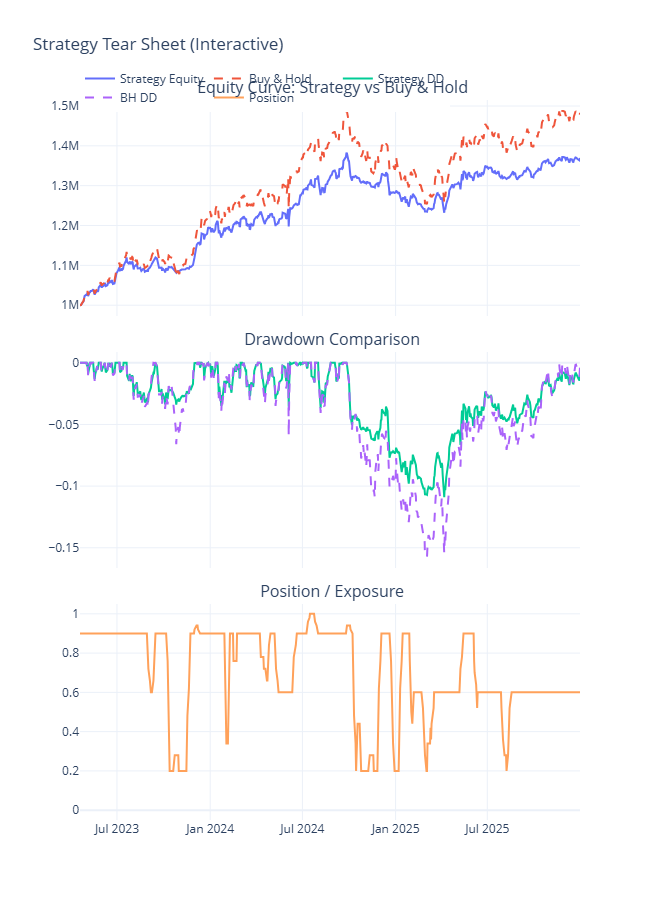

In [50]:
# this block is the final pipeline test of the regime-based trading strategy.
# it takes the o/p of the ML model --> converts them into trading positions --> backtest the idea --> evaluates --> plots the results.
print("TESTING ENHANCED FOUR REGIME STRATEGY...")


# Convert regime signals into position sizing decisions
signals_regime_v2 = four_regime_strategy_clean(signals)   # signals as the i/p here contains the market conditions like Stable_Bull   Stable_Bear  Stable_Low_Vol   High_Vol
                                                                                                                          # 1              0            1                 0
# the function four_regime_strategy converts these conditions into positions like what we decided the exposure in a particular regime.
# Backtest strategy performance with transaction costs
results_regime_v2 = backtest_clean(signals_regime_v2)  

# Compute performance and risk metrics
results, strat_dd, bh_dd = evaluate_clean(results_regime_v2)

# Visualize equity, drawdowns, and position behavior
plot_strategy_results(results_regime_v2, strat_dd, bh_dd)

In [42]:
# this code is now doing a sanity check on the final market regime classification.
## takes the ML- generated regime predictions converts them into one final regime per day, and then counts
# how frequently each regime occured.

# Apply regime-to-position logic and assign one regime per day
out = four_regime_strategy_clean(signals)   # now, signals contains the prediction from random forest models. but, a single day can have multiple
# flags. so, four_regime_classification creates Regime_Final which would create column like LowVol_bull, highvol_bear and accordingly, we have created the position-sizing.

# ---------------------------------------------------------
# Inspect regime frequency distribution
# ---------------------------------------------------------

regime_counts = out["Regime_Final"].value_counts() # now count the unique values of each regime.
print(regime_counts)

Regime_Final
Neutral         519
HighVol_Bear     90
HighVol_Bull     30
LowVol_Bear      16
LowVol_Bull      14
Name: count, dtype: int64


In [43]:

# Analyze signal vs neutral day distribution

# Signal days = days with a clear, actionable regime
signal_days = (out["Regime_Final"] != "Neutral").sum()  # calculates the sum where the regime is not neutral

# Neutral days = no strong or mixed regime signals
no_signal_days = (out["Regime_Final"] == "Neutral").sum()  # calculate the sum where regime is neutral

total_days = len(out)

# ---------------------------------------------------------
# Print signal coverage statistics
# ---------------------------------------------------------
print(f"Total days: {total_days}")
print(f"Signal days: {signal_days} ({signal_days/total_days:.2%})")
print(f"No / Mixed signal days: {no_signal_days} ({no_signal_days/total_days:.2%})")

Total days: 669
Signal days: 150 (22.42%)
No / Mixed signal days: 519 (77.58%)


In [44]:

# Detect conflicting regime signals
# A neutral day can happen because: the model had conflicting signal (bull+bear both active)
# Vol signals conflicted (high vol + low vol both active)
# there was simply no strong regime detected.

# Trend conflict: Bull and Bear signals active simultaneously
bull = out['Stable_Bull'] == 1   # checks if Stable_bull in out df is 1 then return true 
bear = out['Stable_Bear'] == 1   # same as above
low_vol = out['Stable_Low_Vol'] == 1
high_vol = out['High_Volatility'] == 1

# Volatility conflict: Low and High volatility signals overlap
conflict_trend = bull & bear     # final days where Bull and Bear both are active
conflict_vol   = low_vol & high_vol # same as above

# Store conflict flags for diagnostics and sanity checks
out["Trend_Conflict"] = conflict_trend  
out["Vol_Conflict"]   = conflict_vol

# ---------------------------------------------------------
# Diagnose why days are classified as Neutral
# ---------------------------------------------------------
# Neutral days may arise from:
# - Conflicting trend signals
# - Conflicting volatility signals
# - No strong signals at all
neutral = out["Regime_Final"] == "Neutral"

# Breakdown of Neutral days by conflict type
neutral_breakdown = pd.Series({   # creates a pandas series which contains bifurcation why neutral days occur
    "Trend conflict only": (neutral & conflict_trend & ~conflict_vol).sum(),   # neutral days occur because both bull and bear are active but no vol_conflict
    "Vol conflict only":   (neutral & conflict_vol & ~conflict_trend).sum(),   # neutral days occur because both high and low vol conflicts are active but no bull,bear conflict
    "Both conflicts":     (neutral & conflict_trend & conflict_vol).sum(),     # neutral days because both conflicts arise simultaneously.
    "No signals at all":  (neutral & ~conflict_trend & ~conflict_vol).sum()    # neither of the two are active.
})

print(neutral_breakdown)

Trend conflict only      0
Vol conflict only        0
Both conflicts           0
No signals at all      519
dtype: int64


In [45]:
# performing diagnostic check to verify whether the strategy is assigning the correct exposure levels to each market regime.
# group data by final regime like: out hs a column regime_final containing all the regimes so, group by separates rows by regime. for instance:  LowVol_Bull group (jan1, jan2, etc) and same for others.
# Now, foe each regime, only calculate statistice for these three exposure columns.
out.groupby("Regime_Final")[[
    "Position",        # raw regime-based exposure
    "Position_Sticky", # exposure after whipsaw control like significant wiggling in the exposure from 1 to 0.2, sticky makes it 1,1,1 until the regime block changes.
    "Position_Exec"    # final, lagged executable exposure includes proper smoothing, one-day execution lag (to avoid look ahead bias)
]].mean()

,Position,Position_Sticky,Position_Exec
Regime_Final,,,
HighVol_Bear,0.200000,0.200000,0.374889
HighVol_Bull,0.900000,0.900000,0.852000
LowVol_Bear,0.600000,0.600000,0.757500
LowVol_Bull,1.000000,1.000000,0.952857
Neutral,0.853179,0.775145,0.745742


In [46]:
def two_regime_strategy(signals: pd.DataFrame) -> pd.DataFrame:
    # Work on a copy to avoid mutating original signals
    out = signals.copy()

    # Default position
    # Fully invested unless risk conditions are triggered
    out['Position'] = 1.0

    # ---------------------------------------------------------
    # Crash-like risk condition
    # ---------------------------------------------------------
    # Severe risk-off when:
    # - Bear market signal is present
    # - Bear regime is stable (persistent)
    # - Volatility is elevated
    crash_like = (
        (out['Bear_Market'] == 1) &   # means short-term trend is negative
        (out['Stable_Bear'] == 1) &   # bear market is persistent 
        (out['High_Volatility'] == 1)  # the market is stressed
    )  # if all these conditions are satisfies, that means the market is under crash - like situation.

    # ---------------------------------------------------------
    # Mild risk-off condition
    # ---------------------------------------------------------
    # Reduce exposure during stable bear regimes
    mild_risk_off = (
        (out['Stable_Bear'] == 1)
    )   # if market is under stable bear regime, reduce the exposure.

    # ---------------------------------------------------------
    # Position sizing rules
    # ---------------------------------------------------------
    # Moderate de-risking in bear markets
    out.loc[mild_risk_off, 'Position'] = 0.7  # when the mild risk off condition satisfies, then size the postition to 0.7
    # Aggressive de-risking during crash-like conditions
    out.loc[crash_like, 'Position']    = 0.3 # here size the position to 0.3

    # ---------------------------------------------------------
    # Smooth exposure and apply execution lag
    # ---------------------------------------------------------
    # Short smoothing window to avoid abrupt position changes
    out['Position_Smooth'] = out['Position'].rolling(3, min_periods=1).mean()   # same smoothing concept as discussed above.
    # Lag positions by one day to avoid look-ahead bias; seed day 1 with the
    # first available exposure (bfill) for consistency with the 4-regime model.
    out['Position_Exec']   = out['Position_Smooth'].shift(1).bfill()  # fill the first obsevation with the next day's observtion

    return out

 Strategy Evaluation Metrics
Total Return %: 41.84
CAGR % (Strategy): 14.07
BH Return %: 48.31
CAGR % (BH): 16.00
Max Drawdown % (Strategy): -13.54
BH Max Drawdown %: -15.77
Sharpe: 0.73
BH Sharpe: 0.81
Sortino: 0.93
Calmar: 1.04
Win Rate %: 54.71
Avg Position %: 86.23
Annual Vol %: 10.94


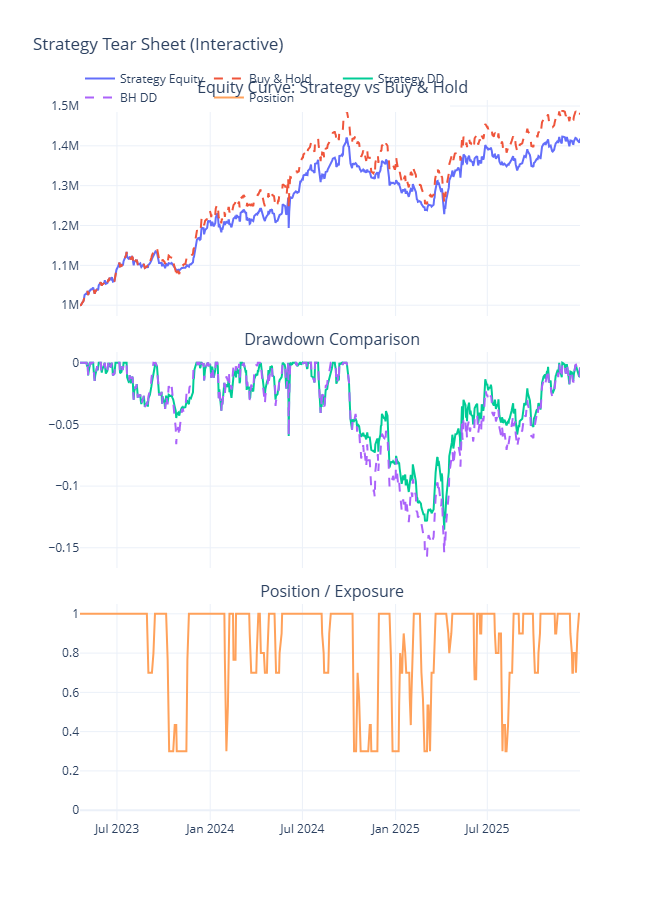

In [47]:
# ---------------------------------------------------------
# Run tail-hedge (crash protection) strategy
# ---------------------------------------------------------
# Convert regime signals into defensive position sizing
signal_r = two_regime_strategy(signals)  # takes signals as input and call function two_regime_strategy

# Backtest tail-hedge strategy with transaction costs
results_tail_hedge = backtest_clean(signal_r)   

# Evaluate performance and risk metrics
results1, strat_dd1, bh_dd1 = evaluate_clean(results_tail_hedge)   # calling the evaluation function and storing the three outputs it returns.
# At the end of the function, it returns o/ps : performance metrics table, strategy drawdown series, buy and hold series
# Visualize equity curve, drawdowns, and exposure behavior
plot_strategy_results(results_tail_hedge, strat_dd1, bh_dd1)  # this function plots the curve of the o/ps.

In [48]:
# this code is an exposure diagnostic. checks whether the strategy is reducing protfolio exposure correctly depending on the bear market state.
# does three things: 
# group days according to bear signals.
# looks at the actual executed positions on those days.
# calculates average exposure.
out.groupby(
    ['Bear_Market', 'Stable_Bear'] # bear_market: raw bear signal, bear_market: persistent bear signal
    
)['Position_Exec'].mean() # Position_exec : raw signal --> position ---> smoothing ---> shift(1) ---> position_exec (final position used in the backtest).
# effectively, it calculates --> for each type of market condition, what was the avg actual portfolio exposure?
## O/p Interpretation:
# Bear_Market = 0
# Stable_Bear = 0   Normal Market position = 1.0
# Bear_Market = 0
# Stable_Bear = 1  # not possible because for stable_bear atleast bear should persist.
#Bear_Market = 1
# Stable_Bear = 0   # early bearish phase, perhaps market started reacting to the conditions but still not confirmed yet.
#Bear_Market = 1
# Stable_Bear = 1   Confirmed Bear Market position = 0.7 approx 



Bear_Market  Stable_Bear
0            0              0.790274
1            0              0.701235
             1              0.524599
Name: Position_Exec, dtype: float64

In [49]:
# ---------------------------------------------------------
# Identify crash-like regime conditions
# ---------------------------------------------------------
# Crash-like = confirmed bear + high volatility + price below long-term trend
crash_like = (
    (out['Bear_Market'] == 1) &
    (out['Stable_Bear'] == 1) &
    (out['High_Volatility'] == 1)
)

# detects when the crash ends (below)
out[['Position_Exec']].loc[   # exctracts only position_exec on those recovery days when the crash ends.
    (crash_like.shift(1) == 1) & (crash_like == 0)   # yesterday was a crash but today no longer a crash.
].head(10) # also, it inspects whether the smoothing logic is working fine as soon after the crash the position exposure should not suddenly jump to 1. If that happens, perhaps our smoothing logic
# is not working fine.

,Position_Exec
Date,
2023-10-20,0.20
2023-11-15,0.20
2024-02-02,0.34
2024-02-16,0.76
2024-10-15,0.20
2024-11-08,0.20
2024-11-26,0.20
2025-01-07,0.20
2025-01-30,0.62


## Summary & Key Takeaways

This project demonstrates that:

- Market regimes can be systematically identified using trend, volatility, and breadth.
- Persistence filters stabilize noisy trend signals.
- Immediate volatility signals improve risk control.
- Regime-based exposure leads to smoother equity curves and better drawdown management.

Rather than predicting prices, the framework focuses on:

> **Adapting intelligently to the market environment.**